In [10]:
# Install required libraries
%pip install pandas numpy scikit-learn matplotlib seaborn nltk joblib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

In [3]:
# Load Dataset

df = pd.read_csv("../data/phishing.csv")

# Remove unnecessary column

df = df.drop(columns=["Unnamed: 0"])

# Remove missing values

df = df.dropna(subset=["Email Text", "Email Type"])

# Convert text column to string

df["Email Text"] = df["Email Text"].astype(str)

# Dataset Information

print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df["Email Type"].value_counts())

df.head()

Dataset Shape: (18634, 2)

Missing Values:
Email Text    0
Email Type    0
dtype: int64

Class Distribution:
Email Type
Safe Email        11322
Phishing Email     7312
Name: count, dtype: int64


,Email Text,Email Type
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,the other side of * galicismos * * galicismo *...,Safe Email
2,re : equistar deal tickets are you still avail...,Safe Email
3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [4]:
# Features and Labels

X = df["Email Text"]

y = df["Email Type"]

# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Extra Safety

X_train = X_train.fillna("").astype(str)
X_test = X_test.fillna("").astype(str)

# TF-IDF

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=10000,
    ngram_range=(1,2)
)

X_train_vec = vectorizer.fit_transform(X_train)

X_test_vec = vectorizer.transform(X_test)

# Logistic Regression

model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train_vec,
    y_train
)

# Predictions

y_pred = model.predict(X_test_vec)

print("Training Completed")

Training Completed


Accuracy: 97.18 %

Classification Report:

                precision    recall  f1-score   support

Phishing Email       0.95      0.97      0.96      1462
    Safe Email       0.98      0.97      0.98      2265

      accuracy                           0.97      3727
     macro avg       0.97      0.97      0.97      3727
  weighted avg       0.97      0.97      0.97      3727



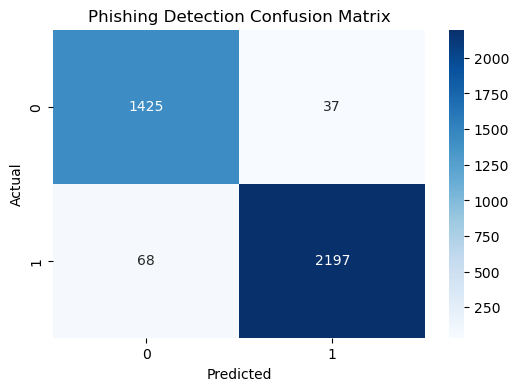


Model Saved Successfully!


In [5]:
# Accuracy

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", round(accuracy * 100, 2), "%")

# Classification Report

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)

# Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Phishing Detection Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Save Model

joblib.dump(
    model,
    "../models/phishing_model.pkl"
)

joblib.dump(
    vectorizer,
    "../models/phishing_vectorizer.pkl"
)

print("\nModel Saved Successfully!")